# 0. Source demo

A demonstration of the newly introduced `Source` class

In [1]:
import logging
from astroquery.vizier import Vizier
from catalog_builder import Source, fetch_xmm_photometry, get_4xmm_luminosities
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
log = logging.getLogger(__name__)
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s|%(levelname)s|%(name)s|%(message)s",
    datefmt="%m/%d/%Y %I:%M:%S %p",
)

In [3]:
# load the CoreG and FR0 catalogues
nagar_2005 = Vizier(columns=["**"], row_limit=-1).get_catalogs("J/A+A/435/521")
fr0cat = Vizier(columns=["**"], row_limit=-1).get_catalogs("J/A+A/609/A1")

# let us take a few sources for each catalogue to play with the functionalities implemented
source_names = [str(_) for _ in nagar_2005[0]["Name"][::20]] + ["SDSS" + _ for _ in fr0cat[0]["SDSS"][::20]]
print(source_names)

['IC239', 'NGC1058', 'NGC3079', 'NGC3608', 'NGC3982', 'NGC4261', 'NGC4457', 'NGC4698', 'NGC5363', 'NGC5982', 'SDSSJ010852.48-003919.4', 'SDSSJ094319.15+361452.1', 'SDSSJ112625.19+520503.5', 'SDSSJ130837.91+434415.1', 'SDSSJ150152.30+174228.2', 'SDSSJ162549.96+402919.4']


In [4]:
# let us turn each of them into a `Source`
sources = [Source(name) for name in source_names]

08/06/2026 03:52:33 PM|WARNING|catalog_builder.catalog_utils|2 SDSS counterparts found for NGC3079 by SIMBAD. Taking the first one: SDSS J100157.94+554047.8
08/06/2026 03:52:33 PM|WARNING|catalog_builder.catalog_utils|full list of counterparts: ['SDSS J100157.94+554047.8' 'SDSS J100158.19+554048.4'] please check on SIMBAD!
08/06/2026 03:52:33 PM|WARNING|catalog_builder.catalog_utils|3 SDSS counterparts found for NGC3982 by SIMBAD. Taking the first one: SDSS J115628.12+550730.8
08/06/2026 03:52:33 PM|WARNING|catalog_builder.catalog_utils|full list of counterparts: ['SDSS J115628.12+550730.8' 'SDSS J115628.13+550730.8'
 'SDSS J115628.13+550731.0'] please check on SIMBAD!
08/06/2026 03:52:33 PM|WARNING|catalog_builder.catalog_utils|2 SDSS counterparts found for NGC4261 by SIMBAD. Taking the first one: SDSS J121923.21+054929.7
08/06/2026 03:52:33 PM|WARNING|catalog_builder.catalog_utils|full list of counterparts: ['SDSS J121923.21+054929.7' 'SDSS J121923.22+054929.7'] please check on SIMBA

In [5]:
print(sources[2])


            name : NGC3079
            ra : 150.49 deg
            dec : 55.68 deg
            z : 0.004
            source_type: *
            sdss_id_simbad: SDSS J100157.94+554047.8
            nvss_id_simbad: NVSS J100157+554048
            first_id_simbad: 
        


## 0.1 Spectral informations from a source
Let us fetch all the line measurements from NED, and let's build its radio SED.

In [6]:
sources[5].lines_flux_table

08/06/2026 03:52:35 PM|INFO|catalog_builder.source|Searching NED line fluxes for source NGC4261


Observed Passband,flux,flux_err,is_ul,unit
object,float64,float64,bool,str9
H{alpha} (TNG),1.1748975549395303e-15,8.224282884576712e-17,False,erg/cm2/s
H{alpha} line (HST),1.91e-15,nan,False,erg/cm2/s
H{alpha}+[NII] (HST),3.2e-14,nan,False,erg/cm2/s
H{alpha}+[NII] (OAN),4.3651583224016657e-14,1.105626332989307e-14,False,erg/cm2/s
H{alpha}+[NII] (OAN),4.073802778041122e-13,3.6583082439209363e-13,False,erg/cm2/s
[O III] 5007,3.71e-14,nan,False,erg/cm2/s


In [7]:
sources[6].radio_flux_table

08/06/2026 03:52:35 PM|INFO|catalog_builder.source|Searching NED radio fluxes for source NGC4457


Observed Passband,flux,flux_err,is_ul,unit
object,float64,float64,bool,str3
15 GHz (VLA),1.0,nan,True,mJy
8.6 GHz Effelsberg,10.0,2.0,False,mJy
4.85 GHz Effelsberg,15.0,3.0,False,mJy
2380 MHz,27.0,4.0,False,mJy
1.4GHz,27.4,1.6,False,mJy
1.4 GHz (VLA),25.2,nan,False,mJy


In [8]:
sources[6].x_ray_flux_table

08/06/2026 03:52:35 PM|INFO|catalog_builder.source|Searching NED X-ray fluxes for source NGC4457


Observed Passband,flux,flux_err,is_ul,unit
object,float64,float64,bool,str9
2-10 keV (Chandra),3.090295432513592e-14,1.707760367004812e-14,False,erg/cm2/s
2-10 keV (Chandra),1.7e-14,1.2e-14,False,erg/cm2/s
2-10 keV (Chandra),3.090295432513592e-14,1.707760367004812e-14,False,erg/cm2/s
2-10 keV (Chandra),1.7e-14,1.2e-14,False,erg/cm2/s
0.3-8 keV (Chandra),1.56e-13,nan,False,erg/cm2/s
0.5-2 keV (Chandra),3.7e-14,1e-15,False,erg/cm2/s
0.5-2.0 keV Chandra,1.4791083881682072e-13,6.811545851037129e-15,False,erg/cm2/s


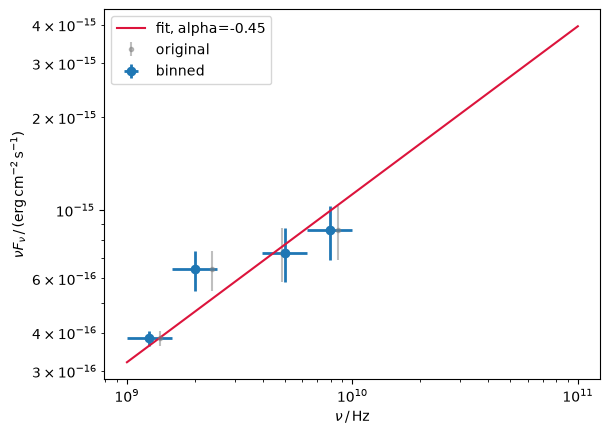

In [9]:
# build and plot the radio SED
fig, ax = plt.subplots()
sources[6].plot_radio_sed(fit=True, ax=ax)
plt.show()

## 0.2 Xmatch from the MORX catalogue
We extract the radio and X-ray information from the MORX catalogue.

In [10]:
sources[3].morx_xmatch_table

08/06/2026 03:52:38 PM|INFO|catalog_builder.crossmatching_x_ray|NGC3608 matched in MORX by name!


Name,RAJ2000,DEJ2000,Type,z,RXpct,Xraypct,XMM-ID,CX-ID,Swift-ID,radiopct,NVSS-ID,FIRST-ID,LoTSS-ID,VLASS-ID,Lobe1,Lobe2,Lobedist
,deg,deg,,,pct,pct,,,,pct,,,,,,,arcsec
str25,float64,float64,str4,float32,int16,int16,str22,str22,str22,int16,str22,str22,str22,str22,str22,str22,int16
NGC 3608,169.2458334,18.1486667,GX,0.004,100,100,4XMM J111659.0+180853,CXO J111659.2+180849,,--,,,,,,,--


In [11]:
sources[6].morx_xmatch_table

08/06/2026 03:52:41 PM|INFO|catalog_builder.crossmatching_x_ray|NGC4457 matched in MORX by name!
08/06/2026 03:52:41 PM|WARNING|catalog_builder.crossmatching_x_ray|Name matches, but NVSS-ID differs! Simbad: NVSS B122625+035049 | MORX: NVSS J122858.9+033411


Name,RAJ2000,DEJ2000,Type,z,RXpct,Xraypct,XMM-ID,CX-ID,Swift-ID,radiopct,NVSS-ID,FIRST-ID,LoTSS-ID,VLASS-ID,Lobe1,Lobe2,Lobedist
,deg,deg,,,pct,pct,,,,pct,,,,,,,arcsec
str25,float64,float64,str4,float32,int16,int16,str22,str22,str22,int16,str22,str22,str22,str22,str22,str22,int16
NGC 4457,187.2460298,3.5706320,GRX,0.003,100,100,,CXO J122859.0+033411,LSXPSJ122859.0+033414,100,NVSS J122858.9+033411,FIRSTJ122859.0+033414,,VLAJ122859.02+033414.3,,,--


## 0.3 X-ray photometry
Now that the X-ray counterparts have been found, search for flux measurements.
Note the function `fetch_xmm_photometry` needs as output the `morx_xmatch_table`

In [12]:
tab = fetch_xmm_photometry(sources[3].morx_xmatch_table)

08/06/2026 03:52:41 PM|INFO|catalog_builder.crossmatching_x_ray|querying for J111659.0+180853 in 4XMM


In [13]:
tab[0]

recno,Source,4XMM,RA_ICRS,DE_ICRS,ePos,srcML,Flux1,e_Flux1,Flux2,e_Flux2,Flux3,e_Flux3,Flux4,e_Flux4,Flux5,e_Flux5,Flux8,e_Flux8,Flux9,e_Flux9,HR1,e_HR1,HR2,e_HR2,HR3,e_HR3,HR4,e_HR4,ext,e_ext,extML,Cst,Fvar,e_Fvar,V,S,F8min,e_F8min,F8max,e_F8max,MJD0,MJD1,Nd,c,uIRAP,xcatDB
,,,deg,deg,arcsec,,mW / m2,mW / m2,mW / m2,mW / m2,mW / m2,mW / m2,mW / m2,mW / m2,mW / m2,mW / m2,mW / m2,mW / m2,mW / m2,mW / m2,,,,,,,,,arcsec,arcsec,,,,,,,mW / m2,mW / m2,mW / m2,mW / m2,d,d,,,,
int32,int64,str16,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,uint8,uint8,float64,float64,float64,float64,float64,float64,int16,uint8,str54,str6
299269,200990301010006,J111659.0+180853,169.245975,18.148294,0.584778,2419.9,2.2091e-14,1.009e-15,4.1836e-14,1.4111e-15,2.4897e-14,1.1717e-15,3.7855e-14,2.6249e-15,2.8458e-14,7.826e-15,1.5585e-13,8.6329e-15,9.4768e-14,2.8026e-15,0.261634,0.026146,-0.316151,0.025922,-0.292059,0.037777,-0.644704,0.067205,10.585839,0.501035,382.54,0.203572,0.160609,0.112036,0,1,1.5355e-13,8.7659e-15,2.2976e-13,4.9745e-14,51870.2336,56067.6031,2,0,http://xmm-catalog.irap.omp.eu/source/200990301010006/,xcatDB


From the this table one can also get the X-ray luminosities, one needs to specify the source distance.

In [14]:
get_4xmm_luminosities(sources[3].morx_xmatch_table, sources[3].d_L)

08/06/2026 03:52:41 PM|INFO|catalog_builder.crossmatching_x_ray|querying for J111659.0+180853 in 4XMM


(np.float64(3.290168219859993e+39),
 np.float64(7.754346822189396e+37),
 np.float64(2.4563470486319644e+39),
 np.float64(3.057590243854274e+38))